# Notebook 4 — Qualities, quantities, units, and threshold classification
## Mary's blood pressure, her tumour grade, her receptor status

Clinical decisions hinge on **features** of the patient — features that come in two ontologically distinct flavours.

Some features are **qualitative**. Tumour grade is *low*, *intermediate*, or *high*; the receptor status of a sample is *positive* or *negative*. There is no underlying number that captures the distinction — the categories are mutually exclusive labels.

Other features are **quantitative**. A systolic blood pressure is *143 mmHg* — a real number with a unit. Two readings can be compared, ordered, averaged. Thresholds matter: at or above 140 mmHg, the reading is in the hypertensive range.

SULO models the two cleanly with two different classes — `Quality` (a kind of `Feature`) and `Quantity` (a kind of `InformationObject` that carries a numeric value and a unit). This notebook anchors both on Mary:

- On Feb 18 at the visit, **three systolic blood pressure readings** are recorded — 118, 142, and 165 mmHg. The reasoner classifies the two ≥ 140 readings as `HypertensiveReading` via a constrained-datatype defined class.
- On Mar 1, the histopathology test on Mary's biopsy specimen records a **tumour grade of 2** — a qualitative class, not a number — and the **receptor status** ER+, PR+, HER2−. The reasoner classifies the specimen under `IntermediateOrHighGradeTumour` and `HormoneReceptorPositive` via defined classes that union or intersect the qualitative options.

Two complementary uses of the SULO `Feature` hierarchy, each picking the right OWL machinery — constrained datatypes for the numeric threshold, disjoint qualitative subclasses for the categorical state.

## Learning objectives

1. Locate `Quality` and `Quantity` correctly in the SULO hierarchy and use the right one for each kind of feature
2. Build a `Quantity` instance with `hasValue` (functional data property), `hasPart some Unit`, and `refersTo` the underlying quality it measures
3. Define a threshold-classified class using `ConstrainedDatatype` and watch the reasoner classify Mary's readings above 140 mmHg as `HypertensiveReading`
4. Model categorical clinical states (tumour grade, receptor status) as disjoint subclasses of `Quality` attached to the specimen via `hasFeature`
5. Define qualitative defined classes using `intersection` and `union` of class expressions, and observe the reasoner classifying Mary's specimen accordingly

## What we will *not* do

- **No new properties.** Only `hasValue`, `hasFeature`, `isFeatureOf`, `hasPart`, and `refersTo` are used — all SULO.
- **No measurement process modelling.** The three BP readings are taken during Mary's Feb 18 visit, but we do not introduce a `BPMeasurement` process — that participation level was covered for the biopsy in NB2 and adds no new lesson here.
- **No bare-int lab values.** Receptor status will *not* be modelled as `hasValue = 0/1`; a categorical clinical state is a qualitative feature, and modelling it as a number conflates two distinct kinds of clinical attribute.

## Setting up

We reload SULO, PRO, and the MIE checkpoint produced by NB3.

In [1]:
import sys, os, datetime
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append("dist")

sulo = get_ontology("dist/sulo.owl").load()
pro  = get_ontology("dist/pro.owl").load()
mie  = get_ontology("dist/mie-03.owl").load()

print(f"MIE classes:                 {len(list(mie.classes()))}")
print(f"MIE individuals:             {len(list(mie.individuals()))}")
print(f"MIE object properties (local): {len(list(mie.object_properties()))}  ← still zero")

MIE classes:                 21
MIE individuals:             44
MIE object properties (local): 0  ← still zero


## §1 — Quality and Quantity in SULO

SULO distinguishes two top-level kinds of feature:

| Class | Position in SULO | What it represents |
|---|---|---|
| `sulo:Quality` | `sulo:Feature` `SubClassOf:` `sulo:Object` | An intrinsic feature of an object — qualitative, categorical |
| `sulo:Quantity` | `sulo:InformationObject` with `hasPart some Unit` | A numeric information item recording the magnitude of some quality, in some unit |

Two important corollaries.

**Quality is attached, not recorded.** A patient *has* a blood pressure quality — it's part of who they are physiologically. The quality is linked to its bearer via `sulo:hasFeature` (object → feature) and its inverse `sulo:isFeatureOf` (feature → object).

**Quantity is recorded, not attached.** A measurement is an *information object* about the world — it carries a `sulo:hasValue` (a functional data property — at most one value per quantity individual), a `sulo:hasPart` of type `Unit`, and a `sulo:refersTo` linking it to the quality (or quality bearer) it measures. Many measurements can refer to the same quality at different points in time, each capturing a different snapshot.

## §2 — Blood pressure as a quantity

We model the systolic blood pressure pattern in three steps.

1. `SystolicBloodPressure` — a `sulo:Quality` subclass. Mary has one instance of it, isFeatureOf her body.
2. `MmHgUnit` — a `sulo:Unit` subclass. One shared instance, used by all measurements.
3. `BPMeasurement` — a `sulo:Quantity` subclass with three class-level commitments:
   - `refersTo some SystolicBloodPressure` — every BP measurement is about a systolic BP quality
   - `hasPart some MmHgUnit` — every BP measurement carries mmHg as its unit (this is a refinement; `Quantity` already requires `hasPart some Unit`)
   - `hasValue some int` — every BP measurement has an integer reading

Mary's three readings on 2026-02-18 are 118, 142, and 165 mmHg.

In [2]:
# Declare the BP vocabulary: quality, unit, and the Quantity class (SOLID pattern)
with mie:
    class SystolicBloodPressure(sulo.Quality):
        """The pressure exerted by circulating blood against arterial walls during ventricular contraction."""
        label = [locstr("systolic blood pressure", "en")]

    class MmHgUnit(sulo.Unit):
        """Millimetres of mercury — the conventional unit of clinical blood pressure measurement."""
        label = [locstr("mmHg", "en")]

    class BPMeasurement(sulo.Quantity):
        """An information object recording a single systolic blood pressure reading in mmHg."""
        label = [locstr("systolic blood pressure measurement", "en")]
        is_a = [
            sulo.refersTo.some(SystolicBloodPressure),
            sulo.hasPart.some(MmHgUnit),
            sulo.hasValue.some(int),
        ]


In [3]:
# Mary's persistent BP quality + three readings during the Feb 18 visit
with mie:
    mary_systolic_bp = SystolicBloodPressure("mary_systolic_bp")
    mary_systolic_bp.isFeatureOf = [mie.mary]

    mmhg = MmHgUnit("mmhg")

    def _bp(name, value):
        m = BPMeasurement(name)
        m.refersTo = [mary_systolic_bp]
        m.hasPart  = [mmhg]
        m.hasValue = value
        return m

    mary_bp_118 = _bp("mary_bp_reading1_feb18", 118)
    mary_bp_142 = _bp("mary_bp_reading2_feb18", 142)
    mary_bp_165 = _bp("mary_bp_reading3_feb18", 165)

print("Mary's BP readings on 2026-02-18:")
for m in [mary_bp_118, mary_bp_142, mary_bp_165]:
    print(f"  - {m.name:30s} value: {m.hasValue} mmHg  refersTo: {[q.name for q in m.refersTo]}")


Mary's BP readings on 2026-02-18:
  - mary_bp_reading1_feb18         value: 118 mmHg  refersTo: ['mary_systolic_bp']
  - mary_bp_reading2_feb18         value: 142 mmHg  refersTo: ['mary_systolic_bp']
  - mary_bp_reading3_feb18         value: 165 mmHg  refersTo: ['mary_systolic_bp']


## §3 — Threshold classification with `ConstrainedDatatype`

Clinical practice defines a *threshold* at 140 mmHg systolic. A single reading at or above this threshold falls in the hypertensive range. In OWL we express this by **constraining the datatype** of `hasValue` and using the constraint inside an equivalent class (Manchester syntax):

```
Class: HypertensiveReading
  EquivalentTo:
    BPMeasurement
      and (hasValue some int[>= 140])
```

`owlready2` exposes the datatype restriction as `ConstrainedDatatype(int, min_inclusive=140)`. When the reasoner sees an individual whose `hasValue` is a literal that satisfies the constraint — Mary's `142` and `165` — it derives membership in `HypertensiveReading`. The 118 mmHg reading does not satisfy the constraint and remains an ordinary `BPMeasurement`.

In [4]:
# Defined class — sufficient condition: BP reading at or above 140 mmHg
with mie:
    class HypertensiveReading(BPMeasurement):
        """A BP measurement whose systolic value is at or above the clinical hypertension threshold of 140 mmHg."""
        label = [locstr("hypertensive reading", "en")]
        equivalent_to = [
            BPMeasurement &
            sulo.hasValue.some(ConstrainedDatatype(int, min_inclusive=140))
        ]

print("Class: HypertensiveReading")
print("  EquivalentTo:")
for c in HypertensiveReading.equivalent_to:
    print(f"    {manchester(c)}")

Class: HypertensiveReading
  EquivalentTo:
    BPMeasurement and hasValue some int[>= 140]


In [5]:
# Reasoner — classify Mary's three readings against the 140 mmHg threshold
result = safe_call_reasoner(mie)
print(f"Reasoner ok:          {result['ok']}")
print(f"Inconsistent classes: {result['inconsistent']}")

print("\nInstances of HypertensiveReading after reasoning:")
for ind in HypertensiveReading.instances():
    print(f"  - {ind.name:30s} value: {ind.hasValue} mmHg")

print("\nAll BP readings on Mary — classified?")
for m in [mary_bp_118, mary_bp_142, mary_bp_165]:
    classified = m in HypertensiveReading.instances()
    print(f"  - {m.name:30s} value: {m.hasValue:3d} mmHg  → hypertensive? {classified}")


Reasoner ok:          True
Inconsistent classes: []

Instances of HypertensiveReading after reasoning:
  - mary_bp_reading2_feb18         value: 142 mmHg
  - mary_bp_reading3_feb18         value: 165 mmHg

All BP readings on Mary — classified?
  - mary_bp_reading1_feb18         value: 118 mmHg  → hypertensive? False
  - mary_bp_reading2_feb18         value: 142 mmHg  → hypertensive? True
  - mary_bp_reading3_feb18         value: 165 mmHg  → hypertensive? True


## §4 — Tumour grade as a *quality*, not a quantity

On Mar 1, the histopathology test on Mary's biopsy specimen records a **tumour grade of 2**. The temptation is to model the grade as a number — `hasValue = 2` — and many clinical datasets do. This is the wrong move ontologically. Tumour grade is *categorical*: Grade 1, Grade 2, Grade 3 are ordered labels for distinct tissue patterns, not points on a continuous scale. Two Grade-2 tumours are not necessarily more similar to each other than to Grade-1s by a *quantitative* margin; the distinction is *qualitative*.

SULO's right answer: subclass `Quality` into the three grade classes, assert them pairwise disjoint, and attach an instance of the appropriate grade to the specimen via `hasFeature`. No numeric value is involved at all.

To make the qualitative classification *do* something, we define `IntermediateOrHighGradeTumour` — the clinically actionable category — using a **union of class expressions** (Manchester syntax):

```
Class: IntermediateOrHighGradeTumour
  EquivalentTo:
    TissueSpecimen
      and (hasFeature some (Grade2 or Grade3))
```

Mary's Grade-2 specimen satisfies this; a Grade-1 specimen would not.

In [6]:
# Tumour grade as a categorical quality with three disjoint sub-classes
with mie:
    class TumourGrade(sulo.Quality):
        """The morphological grade of a malignant neoplasm, reflecting differentiation and aggressiveness."""
        label = [locstr("tumour grade", "en")]

    class Grade1(TumourGrade):
        """Well-differentiated tumour cells closely resembling normal tissue."""
        label = [locstr("grade 1", "en")]

    class Grade2(TumourGrade):
        """Moderately differentiated tumour cells with intermediate-grade features."""
        label = [locstr("grade 2", "en")]

    class Grade3(TumourGrade):
        """Poorly differentiated tumour cells with high-grade, aggressive features."""
        label = [locstr("grade 3", "en")]

    AllDisjoint([Grade1, Grade2, Grade3])


In [7]:
# Defined class for actionable specimens + attach Mary's Grade2 quality
with mie:
    class IntermediateOrHighGradeTumour(mie.TissueSpecimen):
        """A tissue specimen carrying a tumour grade of 2 or 3 — clinically actionable threshold."""
        label = [locstr("intermediate or high grade tumour", "en")]
        equivalent_to = [
            mie.TissueSpecimen &
            sulo.hasFeature.some(Grade2 | Grade3)
        ]

    mary_tumour_grade = Grade2("mary_tumour_grade")
    mie.mary_specimen_feb25.hasFeature = [mary_tumour_grade]


In [8]:
# Reasoner — does the specimen get classified as IntermediateOrHighGradeTumour?
result = safe_call_reasoner(mie)
print(f"Reasoner ok:          {result['ok']}")
print(f"Inconsistent classes: {result['inconsistent']}")

print("\nMary's specimen — features and classifications:")
for f in mie.mary_specimen_feb25.hasFeature:
    types = [c.name for c in f.is_a if hasattr(c,'name')]
    print(f"  hasFeature: {f.name:25s} type: {types}")
print(f"\nIs Mary's specimen IntermediateOrHighGradeTumour? "
      f"{mie.mary_specimen_feb25 in IntermediateOrHighGradeTumour.instances()}")


Reasoner ok:          True
Inconsistent classes: []

Mary's specimen — features and classifications:
  hasFeature: mary_tumour_grade         type: ['Grade2']

Is Mary's specimen IntermediateOrHighGradeTumour? True


## §5 — Receptor status as qualities; intersection-defined classification

Three receptor statuses are routinely assessed on a breast cancer specimen — oestrogen receptor (ER), progesterone receptor (PR), and human epidermal growth factor receptor 2 (HER2). Each is binary in clinical practice: positive or negative. Mary's specimen is **ER+, PR+, HER2−**.

We declare six qualitative classes, paired by `AllDisjoint`. We then define `HormoneReceptorPositive` — clinically, a specimen positive for ER *or* PR — using a **union** under existential restriction (Manchester syntax):

```
Class: HormoneReceptorPositive
  EquivalentTo:
    TissueSpecimen
      and ((hasFeature some ERPositive)
            or (hasFeature some PRPositive))
```

Mary's specimen satisfies *both* disjuncts — either alone would have classified it. A specimen with only ER− and PR− would not.

In [9]:
# Three pairs of disjoint receptor-status qualities (ER, PR, HER2)
with mie:
    class ERPositive(sulo.Quality):
        """Oestrogen receptor positivity in tumour tissue."""
        label = [locstr("ER positive", "en")]
    class ERNegative(sulo.Quality):
        """Oestrogen receptor negativity in tumour tissue."""
        label = [locstr("ER negative", "en")]
    AllDisjoint([ERPositive, ERNegative])

    class PRPositive(sulo.Quality):
        """Progesterone receptor positivity in tumour tissue."""
        label = [locstr("PR positive", "en")]
    class PRNegative(sulo.Quality):
        """Progesterone receptor negativity in tumour tissue."""
        label = [locstr("PR negative", "en")]
    AllDisjoint([PRPositive, PRNegative])

    class HER2Positive(sulo.Quality):
        """HER2 receptor positivity in tumour tissue."""
        label = [locstr("HER2 positive", "en")]
    class HER2Negative(sulo.Quality):
        """HER2 receptor negativity in tumour tissue."""
        label = [locstr("HER2 negative", "en")]
    AllDisjoint([HER2Positive, HER2Negative])


In [10]:
# Defined class using union: HR-positive if ER+ OR PR+
with mie:
    class HormoneReceptorPositive(mie.TissueSpecimen):
        """A tissue specimen positive for at least one of the hormone receptors (ER, PR)."""
        label = [locstr("hormone-receptor positive specimen", "en")]
        equivalent_to = [
            mie.TissueSpecimen &
            (sulo.hasFeature.some(ERPositive) | sulo.hasFeature.some(PRPositive))
        ]

    # Mary's receptor qualities, attached to her specimen
    mary_er_status   = ERPositive("mary_er_status")
    mary_pr_status   = PRPositive("mary_pr_status")
    mary_her2_status = HER2Negative("mary_her2_status")
    mie.mary_specimen_feb25.hasFeature.extend([mary_er_status, mary_pr_status, mary_her2_status])


In [11]:
# Reasoner — both defined classes should fire for Mary's specimen
result = safe_call_reasoner(mie)
print(f"Reasoner ok:          {result['ok']}")
print(f"Inconsistent classes: {result['inconsistent']}")

print("\nMary's specimen — all features:")
for f in mie.mary_specimen_feb25.hasFeature:
    types = [c.name for c in f.is_a if hasattr(c,'name')]
    print(f"  - {f.name:25s} {types}")

print("\nDefined-class memberships of mary_specimen_feb25:")
for cls in [IntermediateOrHighGradeTumour, HormoneReceptorPositive]:
    member = mie.mary_specimen_feb25 in cls.instances()
    print(f"  - {cls.name:35s} {'✓' if member else '✗'}")


Reasoner ok:          True
Inconsistent classes: []

Mary's specimen — all features:
  - mary_tumour_grade         ['Grade2']
  - mary_er_status            ['ERPositive']
  - mary_pr_status            ['PRPositive']
  - mary_her2_status          ['HER2Negative']

Defined-class memberships of mary_specimen_feb25:
  - IntermediateOrHighGradeTumour       ✓
  - HormoneReceptorPositive             ✓


## §6 — Recap: the OWL toolkit for clinical features

Two different clinical-feature patterns, two different OWL toolkits, both anchored on Mary:

| Clinical feature | SULO class | OWL machinery for classification |
|---|---|---|
| Systolic BP reading | `Quantity` with `hasValue` + `hasPart Unit` + `refersTo Quality` | `ConstrainedDatatype` inside an equivalent class — `hasValue some int[>= 140]` |
| Tumour grade | `Quality` subclassed into `Grade1`/`Grade2`/`Grade3`, `AllDisjoint` | Union of qualitative classes inside an existential — `hasFeature some (Grade2 or Grade3)` |
| Receptor status (ER, PR, HER2) | `Quality` subclassed into per-status `Positive`/`Negative`, `AllDisjoint` paired | Disjunction of two existentials — `hasFeature some ERPositive or hasFeature some PRPositive` |

The selection is deliberate. Numeric thresholds — `ConstrainedDatatype`. Categorical states — `Quality` subclasses + `AllDisjoint`. Disjunctive clinical criteria — `or` inside an existential. Each construct earns its place by being the natural match for the feature it expresses. The reasoner does the rest.

## §7 — Save the checkpoint

We save the ontology as `dist/mie-04.owl`. NB5 will reload it and turn to *connections* — spatial containment (the tumour located in the breast), information-to-process reference (the diagnosis statement that refers to the disease), and cross-system identity (Mary's SULO IRI linked via `owl:sameAs` to a mock FHIR `Patient/12345`).

Saved dist/mie-04.owl
  classes:                   37
  individuals:               53
  object properties (local): 0  ← still zero
  data properties (local):   0    ← still zero
  imported ontologies:       ['https://w3id.org/sulo/', 'https://w3id.org/ontostart/pro/']


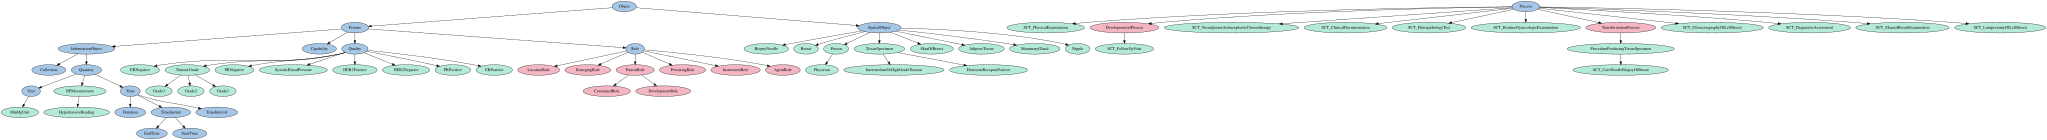

In [12]:
os.makedirs("dist", exist_ok=True)
mie.save(file="dist/mie-04.owl", format="rdfxml")
print("Saved dist/mie-04.owl")
print(f"  classes:                   {len(list(mie.classes()))}")
print(f"  individuals:               {len(list(mie.individuals()))}")
print(f"  object properties (local): {len(list(mie.object_properties()))}  ← still zero")
print(f"  data properties (local):   {len(list(mie.data_properties()))}    ← still zero")
print(f"  imported ontologies:       {[o.base_iri for o in mie.imported_ontologies]}")

tree = get_color_tree([sulo, pro, mie])
display(tree)